In [1]:
from embodied_agent.init_agent_env_and_create_agent import init_agent_env_and_create_agent
from embodied_agent import spf_tools
agent = init_agent_env_and_create_agent()
ctrl = spf_tools._control

GOOGLE模型 gemini-2.5-pro 加载成功, TEMP=0.7
[embodied_agent] 智能体已与ROS2环境及大模型成功绑定


[INFO] [1781240948.651074896] [info_node]: 启动完成
[INFO] [1781240948.655286108] [navigation_node]: 初始化: horizon=15, nav_speed=1.0, dt=0.1, target_z=1.0
[INFO] [1781240948.659449386] [navigation_node]: 启动完成
[INFO] [1781240948.669363433] [navigation_node]: FSM 状态变化: '' -> 'hover_start'


In [ ]:
# --- 测试 get_current_view() ---
from PIL import Image
img: Image.Image = ctrl.get_current_view()
display(img)

In [ ]:
# --- 测试 navigate_to_point() ---
state = ctrl.get_agent_state()
print("当前状态:", state)
cx, cy, cz = state["position"]["x"], state["position"]["y"], state["position"]["z"]
yaw = state["rotation"]["yaw"]
print(f"当前位置: x={cx:.2f}, y={cy:.2f}, z={cz:.2f}")

result = ctrl.navigate_to_point({
    "x": cx + 0.7,
    "y": cy - 0.7,
    "z": cz
})
print("导航结果:", result)

In [ ]:
# --- 测试 navigate_to_point() ---
state = ctrl.get_agent_state()
print("当前状态:", state)
result = ctrl.rotate(150)
print("旋转结果:", result)

In [2]:
config = {"configurable": {"thread_id": "0"}}


🔧 [调用工具] get_current_view
   📥 参数: {}

💬 [Agent]: 好的，任务是找到一个放在架子上的灰色碗。

第一步，我需要先观察一下四周，找找看这个碗在哪里。我会先看看当前的正前方。
   ✅ [工具回复]: The following image shows the robot's current perspective.
   🖼️  [工具返回画面] ↓


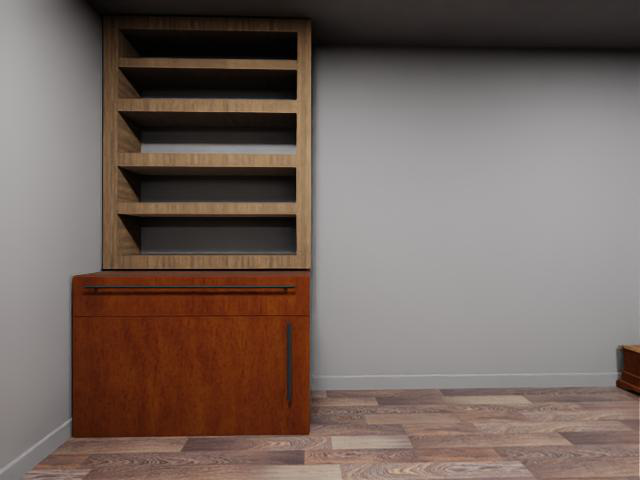

[INFO] [1781240972.068585048] [navigation_node]: FSM 状态变化: 'hover_start' -> 'tracking'



🔧 [调用工具] get_current_position_and_rotation
   📥 参数: {}

💬 [Agent]: 我看到了一个带架子的木制柜子。架子上什么都没有。我现在将向右旋转以寻找一个灰色的碗。
   ✅ [工具回复]: Position: x=0.009(E) y=0.003(N) z=0.979(Up). Yaw: 359.9° ≈ E. Forward vector: (1.00, -0.00) — right is (-0.00, -1.00). (↑yaw=left/CCW, ↓yaw=right/CW)

🔧 [调用工具] rotate
   📥 参数: {'yaw': 300}

💬 [Agent]: 好的，我需要找到一个放在架子上的灰色碗。

1.  **扫描房间：** 我将以60度为增量旋转来寻找目标。我目前的朝向是大约0度，所以我会先向右转（减小偏航角）。
2.  **第一次旋转：** `rotate(yaw=300)` (0 - 60)。
3.  **获取视图：** `get_current_view()` 查看碗是否可见。
4.  **重复：** 如果没找到，我将继续旋转并获取视图，直到完成360度全景扫描。


[INFO] [1781240978.025677653] [navigation_node]: 开始旋转, target_yaw=5.236, current_yaw=-0.004, yaw_diff=1.0430
[INFO] [1781240978.661369441] [navigation_node]: rotating: fsm='tracking', pos=(0.007,-0.016,0.983), yaw_diff=1.0217, target_yaw=5.236, current_yaw=-0.026
[INFO] [1781240979.660841416] [navigation_node]: rotating: fsm='tracking', pos=(0.009,-0.029,1.007), yaw_diff=0.5481, target_yaw=5.236, current_yaw=-0.499
[INFO] [1781240980.661369530] [navigation_node]: rotating: fsm='tracking', pos=(0.011,-0.065,1.027), yaw_diff=0.1405, target_yaw=5.236, current_yaw=-0.907
[INFO] [1781240980.980287975] [navigation_node]: 已到达目标偏航
[INFO] [1781240980.981987624] [navigation_node]: 切换到 HOLD 状态
[INFO] [1781240980.982430847] [navigation_node]: 旋转完成


   ✅ [工具回复]: Rotation successful. Perspective shifted: From yaw=359.85° To yaw=308.53°.

🔧 [调用工具] get_current_view
   📥 参数: {}

💬 [Agent]: 好的，我向右旋转了60度，现在检查一下是否能看到那个灰色的碗。
   ✅ [工具回复]: The following image shows the robot's current perspective.
   🖼️  [工具返回画面] ↓


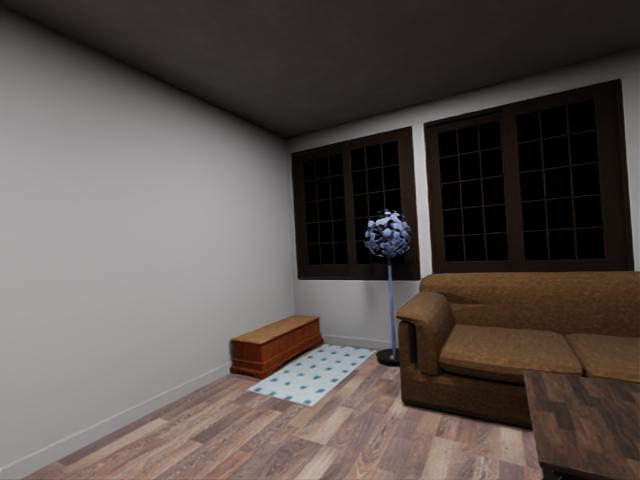


🔧 [调用工具] rotate
   📥 参数: {'yaw': 240}

💬 [Agent]: 我没有看到灰色的碗。 我将向右旋转以继续扫描。


[INFO] [1781240988.663227201] [navigation_node]: 开始旋转, target_yaw=4.189, current_yaw=-1.002, yaw_diff=1.0929
[INFO] [1781240989.661519763] [navigation_node]: rotating: fsm='tracking', pos=(0.008,-0.036,1.002), yaw_diff=0.9273, target_yaw=4.189, current_yaw=-1.167
[INFO] [1781240990.660964408] [navigation_node]: rotating: fsm='tracking', pos=(-0.006,-0.068,1.027), yaw_diff=0.3726, target_yaw=4.189, current_yaw=-1.722
[INFO] [1781240991.560405092] [navigation_node]: 已到达目标偏航
[INFO] [1781240991.562226424] [navigation_node]: 切换到 HOLD 状态
[INFO] [1781240991.562672061] [navigation_node]: 旋转完成


   ✅ [工具回复]: Rotation successful. Perspective shifted: From yaw=302.22° To yaw=250.44°.

🔧 [调用工具] get_current_view
   📥 参数: {}
   ✅ [工具回复]: The following image shows the robot's current perspective.
   🖼️  [工具返回画面] ↓


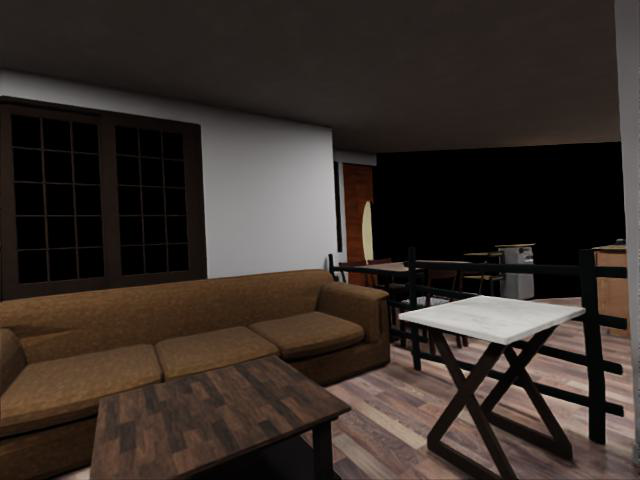


🔧 [调用工具] rotate
   📥 参数: {'yaw': 180}


[INFO] [1781240998.002305815] [navigation_node]: 开始旋转, target_yaw=3.142, current_yaw=-2.066, yaw_diff=1.0758
[INFO] [1781240998.661047442] [navigation_node]: rotating: fsm='tracking', pos=(-0.029,-0.023,0.996), yaw_diff=1.0724, target_yaw=3.142, current_yaw=-2.069
[INFO] [1781240999.661011549] [navigation_node]: rotating: fsm='tracking', pos=(-0.060,-0.020,1.020), yaw_diff=0.5321, target_yaw=3.142, current_yaw=-2.609
[INFO] [1781241000.660603698] [navigation_node]: rotating: fsm='tracking', pos=(-0.086,-0.010,1.036), yaw_diff=0.1207, target_yaw=3.142, current_yaw=-3.021
[INFO] [1781241000.900471367] [navigation_node]: 已到达目标偏航
[INFO] [1781241000.901934501] [navigation_node]: 切换到 HOLD 状态
[INFO] [1781241000.902309540] [navigation_node]: 旋转完成


   ✅ [工具回复]: Rotation successful. Perspective shifted: From yaw=242.36° To yaw=189.52°.

🔧 [调用工具] get_current_view
   📥 参数: {}
   ✅ [工具回复]: The following image shows the robot's current perspective.
   🖼️  [工具返回画面] ↓


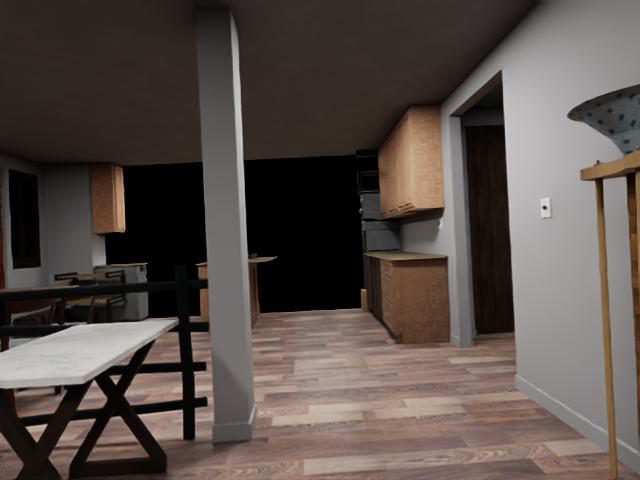


🔧 [调用工具] get_target_object
   📥 参数: {'instruction': '一个带架子的灰色的碗'}

💬 [Agent]: 我看到一个带架子的灰色的碗。我现在将导航到它。
   ✅ [工具回复]: Target '一个带架子的灰色的碗' found at world coordinates: x=-0.70, y=0.47, z=0.99. You can now use navigate_to_point with these coordinates.

🔧 [调用工具] get_current_position_and_rotation
   📥 参数: {}
   ✅ [工具回复]: Position: x=-0.105(E) y=-0.002(N) z=0.986(Up). Yaw: 182.4° ≈ W. Forward vector: (-1.00, -0.04) — right is (-0.04, 1.00). (↑yaw=left/CCW, ↓yaw=right/CW)

🔧 [调用工具] navigate_to_point
   📥 参数: {'x': -0.7, 'z': 0.986, 'y': 0.47}


[INFO] [1781241023.271377865] [navigation_node]: 开始旋转, target_yaw=2.457, current_yaw=-3.101, yaw_diff=0.7249
[INFO] [1781241023.660844667] [navigation_node]: rotating: fsm='tracking', pos=(-0.110,-0.010,0.987), yaw_diff=0.7248, target_yaw=2.457, current_yaw=-3.101
[INFO] [1781241024.661411225] [navigation_node]: rotating: fsm='tracking', pos=(-0.100,-0.005,1.006), yaw_diff=0.3010, target_yaw=2.457, current_yaw=2.758
[INFO] [1781241025.180585461] [navigation_node]: 已到达目标偏航
[INFO] [1781241025.182698828] [navigation_node]: 开始导航, target=(-0.700,0.470,0.986), current=(-0.094,0.013,1.020), dist_xy=0.759, dist_z=0.034, move_yaw=2.457, nav_speed=1.0
[INFO] [1781241025.661420557] [navigation_node]: moving: fsm='tracking', pos=(-0.095,0.028,1.031), target=(-0.700,0.470), dist_xy=0.749, yaw_cmd=2.457
[INFO] [1781241026.660995532] [navigation_node]: moving: fsm='tracking', pos=(-0.125,0.034,1.034), target=(-0.700,0.470), dist_xy=0.722, yaw_cmd=2.457
[INFO] [1781241027.661136004] [navigation_node]:

   ✅ [工具回复]: Navigation failed: Blocked by obstacle. Check if target is already reached via get_current_view and describe how close it is. If NOT reached, you MUST call rotate to scan, then try to nav again.. Current position: (x=-0.68, y=0.46, z=0.99, yaw=140.77°).

🔧 [调用工具] get_current_view
   📥 参数: {}

💬 [Agent]: 我遇到了障碍物，但我离目标很近。 我现在检查一下是否到达了目的地。
   ✅ [工具回复]: The following image shows the robot's current perspective.
   🖼️  [工具返回画面] ↓


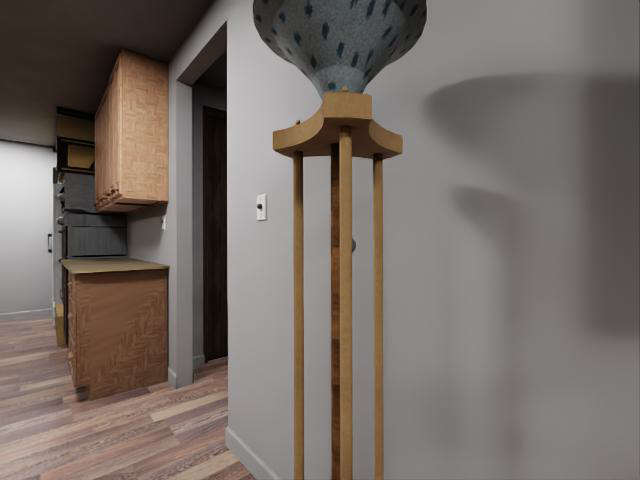


💬 [Agent]: 我到了，一个灰色的碗，下面有一个木架子。


In [3]:
import base64
from io import BytesIO
from PIL import Image

config = {"configurable": {"thread_id": "bowl_task"}}

for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "导航到一个灰色的碗,碗下有个架子"}]},
    config=config,
    stream_mode="updates"
):
    for node_name, update in chunk.items():
        if node_name in ("agent", "model"):
            messages = update.get("messages", [])
            for msg in messages:
                if hasattr(msg, "tool_calls") and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f"\n🔧 [调用工具] {tc['name']}")
                        print(f"   📥 参数: {tc['args']}")
                text = getattr(msg, "content", "")
                if isinstance(text, list):
                    text = " ".join(
                        block.get("text", "") for block in text
                        if isinstance(block, dict) and block.get("type") == "text"
                    )
                if text:
                    print(f"\n💬 [Agent]: {text[:500]}")

        elif node_name == "tools":
            messages = update.get("messages", [])
            for msg in messages:
                content = msg.content
                # ---- 图片检测 ----
                if isinstance(content, list):
                    for block in content:
                        if isinstance(block, dict) and block.get("type") == "text":
                            text = block["text"]
                            if len(text) > 300:
                                text = text[:300] + "..."
                            print(f"   ✅ [工具回复]: {text}")
                        elif isinstance(block, dict) and block.get("type") == "image_url":
                            b64 = block["image_url"]["url"]
                            if b64.startswith("data:image/jpeg;base64,"):
                                b64 = b64[len("data:image/jpeg;base64,"):]
                            img_data = base64.b64decode(b64)
                            img = Image.open(BytesIO(img_data))
                            print(f"   🖼️  [工具返回画面] ↓")
                            display(img)
                else:
                    content_str = str(content)
                    if len(content_str) > 300:
                        content_str = content_str[:300] + "..."
                    print(f"   ✅ [工具回复]: {content_str}")


In [ ]:
ctrl.close()